# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [33]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [34]:
X_train.shape

(60000, 28, 28)

In [35]:
y_train.shape

(60000,)

In [36]:
y_train.shape[0]

60000

In [37]:
X_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

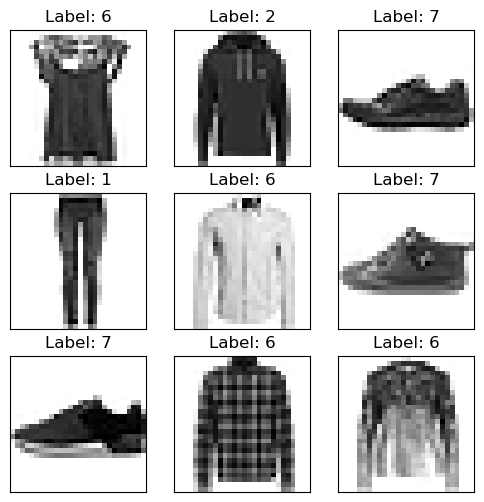

In [38]:
import matplotlib.pyplot as plt
import numpy as np
# Verify the data looks as expected

random_indices = np.random.choice(len(X_train), 9, replace=False)

# Creating a 3x3 grid plot
fig, axes = plt.subplots(3, 3, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[random_indices[i]], cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title(f"Label: {y_train[random_indices[i]]}")

    # Removing axis labels
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

In [39]:
# Inspect the shapes of the datasets


# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical

print(f'Before one-hot encoding: {y_train[0]}')
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)
print(f'After one-hot encoding: {y_train[0]}')

Before one-hot encoding: 9
After one-hot encoding: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [40]:
X_train.shape[1]

28

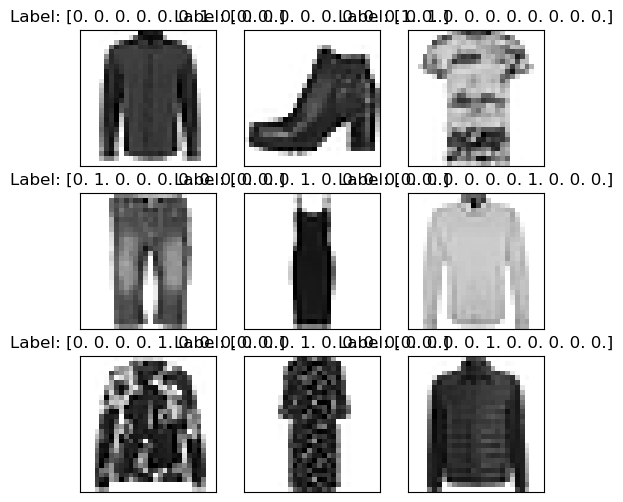

In [41]:
import matplotlib.pyplot as plt
import numpy as np
# Verify the data looks as expected

random_indices = np.random.choice(len(X_train), 9, replace=False)

# Creating a 3x3 grid plot
fig, axes = plt.subplots(3, 3, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[random_indices[i]], cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title(f"Label: {y_train[random_indices[i]]}")

    # Removing axis labels
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()


Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

**Your answer here**

The images have low resolutions. The labels are have been one-hot-coded

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [42]:
'''
from keras.models import Sequential
from keras.layers import Input, Dense, Flatten

# Create a simple linear regression model
model = Sequential()
# You can use `model.add(<layer>)` to add layers to the model
#model.add(Input(shape=(X_train.shape[1],)))  # Input tensor specifying the shape
model.add(Input(shape=(28,28)))  # Input tensor specifying the shape
#model.add(Flatten((Input(shape=(28,)))))  # Input tensor specifying the shape
#model.add(Dense(64, activation='relu'))  # 64 neurons, ReLU activation


# Hidden layer
#model.add(Dense(64, activation='relu'))  # 64 neurons, ReLU activation

# Output layer
#model.add(Dense(10, activation='softmax'))  # 10 neurons, softmax activation
model.add(Flatten())
model.add(Dense(10))  # 10 neurons,

model.summary()
X_train = X_train.reshape((X_train.shape[0], 28 * 28))
X_test = X_test.reshape((X_test.shape[0], 28 * 28))

'''



"\nfrom keras.models import Sequential\nfrom keras.layers import Input, Dense, Flatten\n\n# Create a simple linear regression model\nmodel = Sequential()\n# You can use `model.add(<layer>)` to add layers to the model\n#model.add(Input(shape=(X_train.shape[1],)))  # Input tensor specifying the shape\nmodel.add(Input(shape=(28,28)))  # Input tensor specifying the shape\n#model.add(Flatten((Input(shape=(28,)))))  # Input tensor specifying the shape\n#model.add(Dense(64, activation='relu'))  # 64 neurons, ReLU activation\n\n\n# Hidden layer\n#model.add(Dense(64, activation='relu'))  # 64 neurons, ReLU activation\n\n# Output layer\n#model.add(Dense(10, activation='softmax'))  # 10 neurons, softmax activation\nmodel.add(Flatten())\nmodel.add(Dense(10))  # 10 neurons,\n\nmodel.summary()\nX_train = X_train.reshape((X_train.shape[0], 28 * 28))\nX_test = X_test.reshape((X_test.shape[0], 28 * 28))\n\n"

In [32]:
from keras.models import Sequential
from keras.layers import Input, Dense, Flatten

# Create a simple linear regression model
model = Sequential()

model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(10, activation='softmax'))

model.summary()


c:\Users\Mo\miniconda3\envs\dsi_participant\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
# Compile the model using `model.compile()`
from tensorflow.keras.optimizers import Adam
model.compile(
    loss='categorical_crossentropy', # Loss function
    optimizer=Adam(), # Optimizer
    metrics=['accuracy'] # Metrics to evaluate the model
)


In [14]:
y_train.shape

(60000, 10)

In [15]:
y_train.shape[0]

60000

In [16]:
X_train.shape

(60000, 784)

In [46]:
# Train the model with `model.fit()`

model.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=5, # Number of epochs
    batch_size=28, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)

Epoch 1/5
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.7340 - loss: 0.7902 - val_accuracy: 0.8335 - val_loss: 0.4920
Epoch 2/5
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8384 - loss: 0.4704 - val_accuracy: 0.8353 - val_loss: 0.4688
Epoch 3/5
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8472 - loss: 0.4511 - val_accuracy: 0.8413 - val_loss: 0.4612
Epoch 4/5
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.8542 - loss: 0.4244 - val_accuracy: 0.8388 - val_loss: 0.4579
Epoch 5/5
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8581 - loss: 0.4121 - val_accuracy: 0.8497 - val_loss: 0.4329


In [47]:
# Evaluate the model with `model.evaluate()`
loss, accuracy = model.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8411 - loss: 0.4473
Loss:     0.46
Accuracy: 83.71%


Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

**Your answer here**
I think it's fine but it could be better. I expected up to 95% accuracy!

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [180]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from keras.layers import Conv2D

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model1 = Sequential()

#model = models.Sequential()

# First convolutional block
model1.add(layers.Conv2D(28, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model1.add(layers.MaxPooling2D((2, 2)))

# Second convolutional block
model1.add(layers.Conv2D(64, (3, 3), activation='relu'))
model1.add(layers.MaxPooling2D((2, 2)))

# Third convolutional block
model1.add(layers.Conv2D(64, (3, 3), activation='relu'))

# 3. Add Dense layers on top
# Flatten the output of the convolutional layers
model1.add(layers.Flatten())

# Add a fully connected layer
model1.add(layers.Dense(64, activation='relu'))

# Add the output layer with 10 units for the 10 classes
model1.add(layers.Dense(10,activation='softmax'))

# Print a summary of the model's layers and parameters
model1.summary()



# Train the model

# Evaluate the model

Model: "sequential_49"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_60 (Conv2D)              │ (None, 26, 26, 28)     │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ (None, 13, 13, 28)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 11, 11, 64)     │        16,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_24 (Flatten)            │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_98 (Dense)                │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_99 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 90,978 (355.38 KB)

 Trainable params: 90,978 (355.38 KB)

 Non-trainable params: 0 (0.00 B)

Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

**Your answer here**

In [181]:
from tensorflow.keras.optimizers import Adam
model1.compile(
    loss='categorical_crossentropy', # Loss function
    optimizer=Adam(), # Optimizer
    metrics=['accuracy'] # Metrics to evaluate the model
)


In [182]:
model1.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=5, # Number of epochs
    batch_size=28, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)

Epoch 1/5
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 46s 24ms/step - accuracy: 0.7237 - loss: 0.7448 - val_accuracy: 0.8450 - val_loss: 0.4202
Epoch 2/5
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 39s 22ms/step - accuracy: 0.8695 - loss: 0.3598 - val_accuracy: 0.8817 - val_loss: 0.3296
Epoch 3/5
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 36s 21ms/step - accuracy: 0.8906 - loss: 0.2946 - val_accuracy: 0.8917 - val_loss: 0.2884
Epoch 4/5
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 39s 22ms/step - accuracy: 0.9032 - loss: 0.2630 - val_accuracy: 0.8965 - val_loss: 0.2876
Epoch 5/5
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 47s 27ms/step - accuracy: 0.9125 - loss: 0.2356 - val_accuracy: 0.9001 - val_loss: 0.2827


In [183]:
# Evaluate the model with `model.evaluate()`
loss, accuracy = model1.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8954 - loss: 0.2976
Loss:     0.29
Accuracy: 89.54%


CNN performed btter because CNN is a better model for graphics, with many layers embeded in the model. CNN had 89% accurracy versus baseline with 83% accurracy, difference of 6%

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [185]:
# A. Test Hyperparameters
# Change Kernel size to (5,5)
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from keras.layers import Conv2D

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model2= Sequential()

#model = models.Sequential()

# First convolutional block
model2.add(layers.Conv2D(28, (5, 5), activation='relu', input_shape=(28, 28, 1)))
model2.add(layers.MaxPooling2D((2, 2)))

# Second convolutional block
model2.add(layers.Conv2D(64, (3, 3), activation='relu'))
model2.add(layers.MaxPooling2D((2, 2)))

# Third convolutional block
model2.add(layers.Conv2D(64, (3, 3), activation='relu'))

# 3. Add Dense layers on top
# Flatten the output of the convolutional layers
model2.add(layers.Flatten())

# Add a fully connected layer
model2.add(layers.Dense(64, activation='relu'))

# Add the output layer with 10 units for the 10 classes
model2.add(layers.Dense(10,activation='softmax'))

# Print a summary of the model's layers and parameters
model2.summary()

Model: "sequential_51"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_66 (Conv2D)              │ (None, 24, 24, 28)     │           728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_49 (MaxPooling2D) │ (None, 12, 12, 28)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_67 (Conv2D)              │ (None, 10, 10, 64)     │        16,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_50 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_68 (Conv2D)              │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_26 (Flatten)            │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_102 (Dense)               │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_103 (Dense)               │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,426 (357.13 KB)

 Trainable params: 91,426 (357.13 KB)

 Non-trainable params: 0 (0.00 B)

In [186]:
from tensorflow.keras.optimizers import Adam
model2.compile(
    loss='categorical_crossentropy', # Loss function
    optimizer=Adam(), # Optimizer
    metrics=['accuracy'] # Metrics to evaluate the model
)

model2.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=5, # Number of epochs
    batch_size=28, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)

Epoch 1/5
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.7317 - loss: 0.7298 - val_accuracy: 0.8554 - val_loss: 0.3895
Epoch 2/5
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 44s 25ms/step - accuracy: 0.8744 - loss: 0.3429 - val_accuracy: 0.8832 - val_loss: 0.3252
Epoch 3/5
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 40s 23ms/step - accuracy: 0.8914 - loss: 0.2953 - val_accuracy: 0.9003 - val_loss: 0.2713
Epoch 4/5
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 40s 23ms/step - accuracy: 0.9067 - loss: 0.2560 - val_accuracy: 0.8950 - val_loss: 0.2879
Epoch 5/5
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 35s 20ms/step - accuracy: 0.9166 - loss: 0.2276 - val_accuracy: 0.9045 - val_loss: 0.2635


In [187]:
# Evaluate the model with `model.evaluate()`
loss, accuracy = model2.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9016 - loss: 0.2763
Loss:     0.28
Accuracy: 90.27%


In [191]:
# B. Test presence or absence of regularization
# Set dropout to 0.5
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from keras.layers import Conv2D,Dropout

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model3= Sequential()

#model = models.Sequential()

# First convolutional block
model3.add(layers.Conv2D(28, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model3.add(layers.MaxPooling2D((2, 2)))
model3.add(Dropout(0.25))

# Second convolutional block
model3.add(layers.Conv2D(64, (3, 3), activation='relu'))
model3.add(layers.MaxPooling2D((2, 2)))
model3.add(Dropout(0.25))


# Third convolutional block
model3.add(layers.Conv2D(128, (3, 3), activation='relu'))
model3.add(Dropout(0.25))


# 3. Add Dense layers on top
# Flatten the output of the convolutional layers
model3.add(layers.Flatten())

# Add a fully connected layer
model3.add(layers.Dense(256, activation='relu'))
model3.add(Dropout(0.25))


# Add the output layer with 10 units for the 10 classes
model3.add(layers.Dense(10,activation='softmax'))

# Print a summary of the model's layers and parameters
model3.summary()


Model: "sequential_53"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_72 (Conv2D)              │ (None, 26, 26, 28)     │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_53 (MaxPooling2D) │ (None, 13, 13, 28)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 13, 13, 28)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_73 (Conv2D)              │ (None, 11, 11, 64)     │        16,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_54 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_74 (Conv2D)              │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_28 (Flatten)            │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_106 (Dense)               │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_107 (Dense)               │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 388,066 (1.48 MB)

 Trainable params: 388,066 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

In [192]:
from tensorflow.keras.optimizers import Adam
model3.compile(
    loss='categorical_crossentropy', # Loss function
    optimizer=Adam(), # Optimizer
    metrics=['accuracy'] # Metrics to evaluate the model
)

model3.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=5, # Number of epochs
    batch_size=28, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)

Epoch 1/5
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 80s 43ms/step - accuracy: 0.7050 - loss: 0.7942 - val_accuracy: 0.8554 - val_loss: 0.3894
Epoch 2/5
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 48s 28ms/step - accuracy: 0.8520 - loss: 0.4045 - val_accuracy: 0.8801 - val_loss: 0.3298
Epoch 3/5
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 57s 33ms/step - accuracy: 0.8742 - loss: 0.3427 - val_accuracy: 0.8909 - val_loss: 0.2879
Epoch 4/5
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 43s 25ms/step - accuracy: 0.8834 - loss: 0.3167 - val_accuracy: 0.8971 - val_loss: 0.2740
Epoch 5/5
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 38s 22ms/step - accuracy: 0.8908 - loss: 0.2931 - val_accuracy: 0.9019 - val_loss: 0.2652


In [193]:
# Evaluate the model with `model.evaluate()`
loss, accuracy = model3.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8958 - loss: 0.2861
Loss:     0.28
Accuracy: 89.49%


Please note that the accuracy of 0.25 Dropout at 89.49% is not better than model1 without dropout at 89.54%, with all other settings kept constant.
However, Kernel in model2 at (5,5) has accuracy of 90.2% which i better than model1 at at 89%,with all other settings kept constant.

My final model will be set at kernerl (5,5) and no dropout will be set.

Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

**Your answer here**

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [194]:

#Final test done with kernel (5,5) and no Dropout
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from keras.layers import Conv2D,Dropout

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model4= Sequential()

#model = models.Sequential()

# First convolutional block
model4.add(layers.Conv2D(28, (5, 5), activation='relu', input_shape=(28, 28, 1)))
model4.add(layers.MaxPooling2D((2, 2)))
#model4.add(Dropout(0.25))

# Second convolutional block
model4.add(layers.Conv2D(64, (3, 3), activation='relu'))
model4.add(layers.MaxPooling2D((2, 2)))
#model4.add(Dropout(0.25))


# Third convolutional block
model4.add(layers.Conv2D(128, (3, 3), activation='relu'))
#model4.add(Dropout(0.25))


# 3. Add Dense layers on top
# Flatten the output of the convolutional layers
model4.add(layers.Flatten())

# Add a fully connected layer
model4.add(layers.Dense(256, activation='relu'))
#model4.add(Dropout(0.5))


# Add the output layer with 10 units for the 10 classes
model4.add(layers.Dense(10,activation='softmax'))

# Print a summary of the model's layers and parameters
model4.summary()

c:\Users\Mo\miniconda3\envs\dsi_participant\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_54"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_75 (Conv2D)              │ (None, 24, 24, 28)     │           728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_55 (MaxPooling2D) │ (None, 12, 12, 28)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_76 (Conv2D)              │ (None, 10, 10, 64)     │        16,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_56 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_77 (Conv2D)              │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_29 (Flatten)            │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_108 (Dense)               │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_109 (Dense)               │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 388,514 (1.48 MB)

 Trainable params: 388,514 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

In [195]:
from tensorflow.keras.optimizers import Adam
model4.compile(
    loss='categorical_crossentropy', # Loss function
    optimizer=Adam(), # Optimizer
    metrics=['accuracy'] # Metrics to evaluate the model
)

model4.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=5, # Number of epochs
    batch_size=28, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)

Epoch 1/5
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 67s 36ms/step - accuracy: 0.7437 - loss: 0.6904 - val_accuracy: 0.8572 - val_loss: 0.3885
Epoch 2/5
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 53s 31ms/step - accuracy: 0.8775 - loss: 0.3343 - val_accuracy: 0.8897 - val_loss: 0.3076
Epoch 3/5
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 38s 22ms/step - accuracy: 0.8997 - loss: 0.2724 - val_accuracy: 0.9018 - val_loss: 0.2722
Epoch 4/5
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 43s 25ms/step - accuracy: 0.9076 - loss: 0.2441 - val_accuracy: 0.9037 - val_loss: 0.2616
Epoch 5/5
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 50s 29ms/step - accuracy: 0.9198 - loss: 0.2137 - val_accuracy: 0.9072 - val_loss: 0.2613


Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

**Your answer here**

In [196]:
loss, accuracy = model4.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9011 - loss: 0.2838
Loss:     0.28
Accuracy: 90.09%


CNN is better model with activation function included. I was also able to improve CNN by tunning it with better parameter, in this case 
a kernnel value (5,5). Achieved accurracy of 90%

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.